In [26]:
import numpy as np
import pandas as pd

In [27]:
df = pd.read_csv('seeds.csv')
df

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,species
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,0
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,2
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,2
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,2
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,2


In [28]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

scaledFeatures = MinMaxScaler().fit_transform(df[df.columns[0:7]])
labels = df.species

<function matplotlib.pyplot.show(close=None, block=None)>

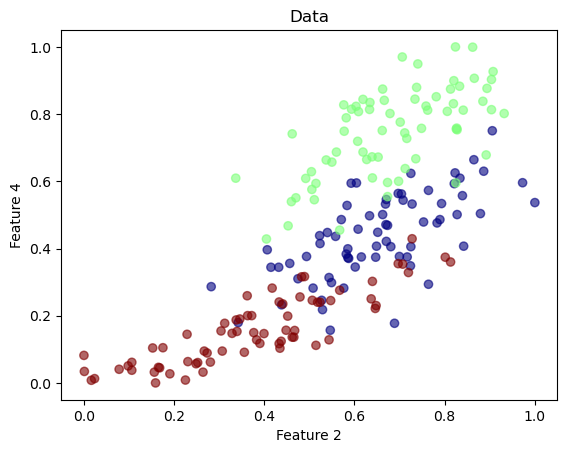

In [29]:
import matplotlib.pyplot as plt

cmap = plt.cm.jet
plt.scatter(scaledFeatures[:,2],scaledFeatures[:,4], alpha = 0.6, c = labels, cmap = cmap)
plt.xlabel('Feature 2')
plt.ylabel('Feature 4')
plt.title('Data')
plt.show


# Get the Principal Components

In [30]:
pca = PCA(n_components = 2).fit(scaledFeatures)
reducedFeatures = pca.transform(scaledFeatures)
reducedFeatures[0:10]

array([[ 0.07502933,  0.12969116],
       [-0.02430059,  0.36411968],
       [-0.14937464,  0.45649725],
       [-0.18088051,  0.44055742],
       [ 0.25058879,  0.44129658],
       [-0.11363851,  0.36902075],
       [-0.04378114,  0.10966172],
       [-0.13412921,  0.31501281],
       [ 0.43988919,  0.00147033],
       [ 0.35028428,  0.18923482]])

<function matplotlib.pyplot.show(close=None, block=None)>

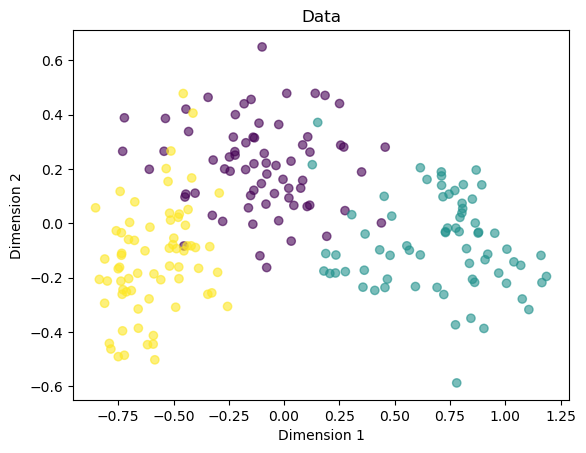

In [31]:
plt.scatter(reducedFeatures[:,0],reducedFeatures[:,1], alpha = 0.6, c = labels, cmap = "viridis")
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Data')
plt.show

# Explained Variance

In [32]:
pca.explained_variance_ratio_

array([0.78903362, 0.1290949 ])

In [33]:
PCA(n_components = 3).fit(scaledFeatures).explained_variance_ratio_

array([0.78903362, 0.1290949 , 0.06866698])

Text(0, 0.5, 'Variance Ratio')

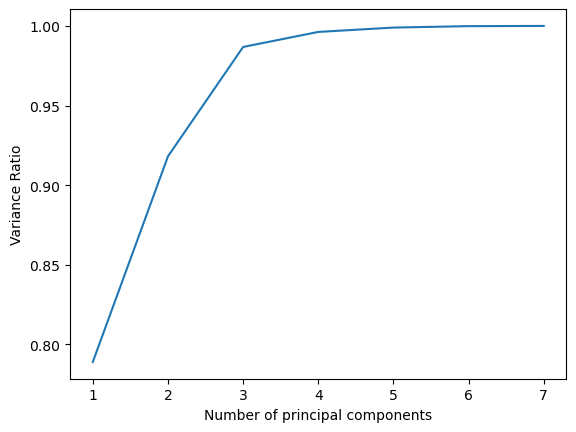

In [34]:
evr = PCA(n_components = 7).fit(scaledFeatures).explained_variance_ratio_
plt.plot(range(1, 8), np.cumsum(evr))
plt.xlabel('Number of principal components')
plt.ylabel('Variance Ratio')
# 7 components is not like 7 features

In [35]:
np.cumsum(evr)

array([0.78903362, 0.91812852, 0.9867955 , 0.99622681, 0.99896561,
       0.99985891, 1.        ])

# Dataset with large number of features

In [36]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

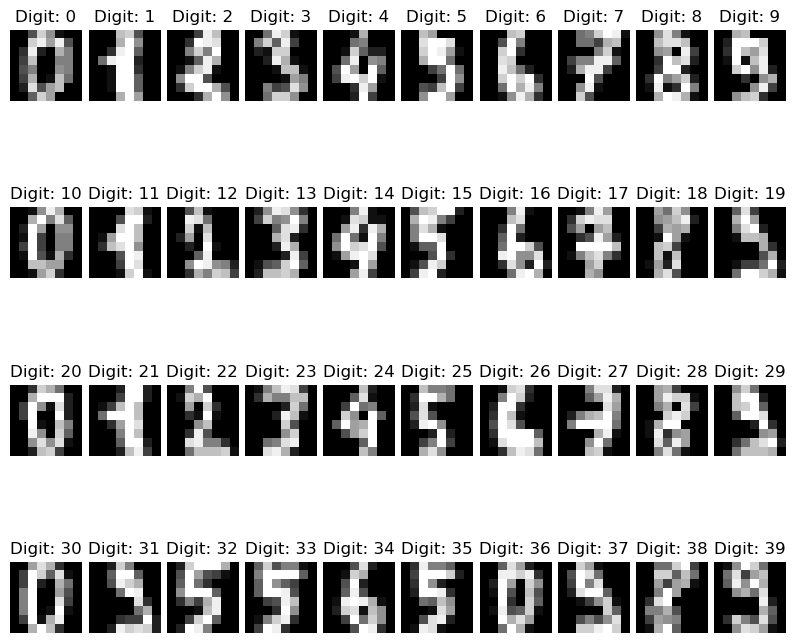

In [37]:
def plot_digits(data):
    fig, ax = plt.subplots(4, 10, figsize=(10, 9),subplot_kw={'xticks':[], 'yticks':[]},gridspec_kw=dict(hspace=0.1,wspace=0.1))
    for i , ax in enumerate(ax.flat):
        ax.imshow(data[i].reshape(8, 8), cmap='gray', interpolation='nearest', clim=(0, 16))
        ax.set_title(f'Digit: {i}')
        ax.axis('off')
plot_digits(digits.data)

In [38]:
pca = PCA(2)
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.data.shape)

(1797, 64)
(1797, 2)


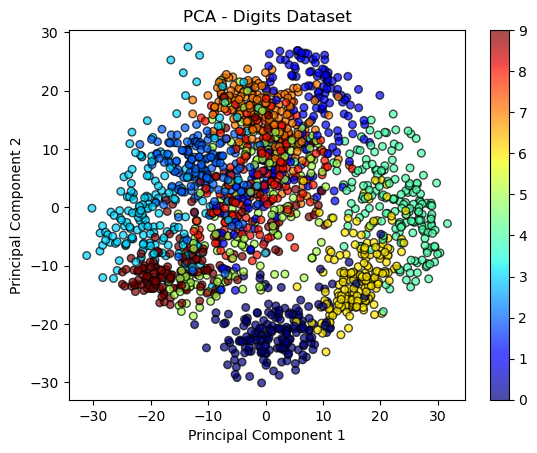

In [39]:
plt.scatter(projected[:, 0], projected[:, 1], c=digits.target, cmap=cmap, edgecolor='k', s=30 , alpha=0.7)
plt.colorbar()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Digits Dataset')
plt.show()

Text(0, 0.5, 'Variance Ratio')

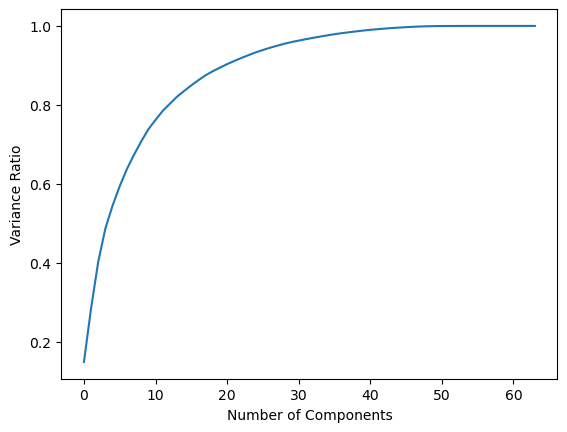

In [40]:
pca = PCA().fit(digits.data)
evr = np.cumsum(pca.explained_variance_ratio_)
plt.plot(evr)
plt.xlabel("Number of Components")
plt.ylabel("Variance Ratio")

In [41]:
evr[1:10]

array([0.28509365, 0.40303959, 0.48713938, 0.54496353, 0.59413263,
       0.6372925 , 0.67390623, 0.70743871, 0.73822677])

# PCA as noise filtering method

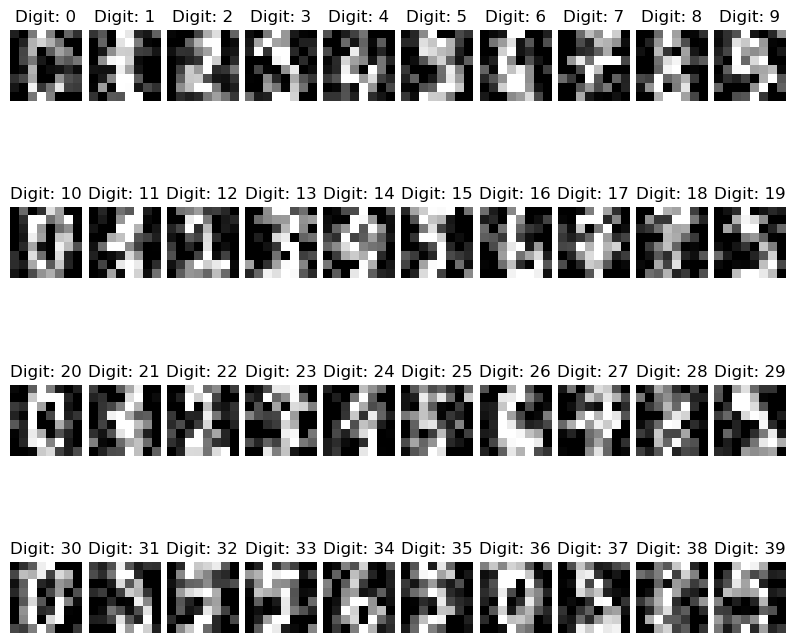

In [45]:
np.random.seed(42)
noisy = np.random.normal(digits.data, 4)
plot_digits(noisy)

In [46]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

np.int64(12)

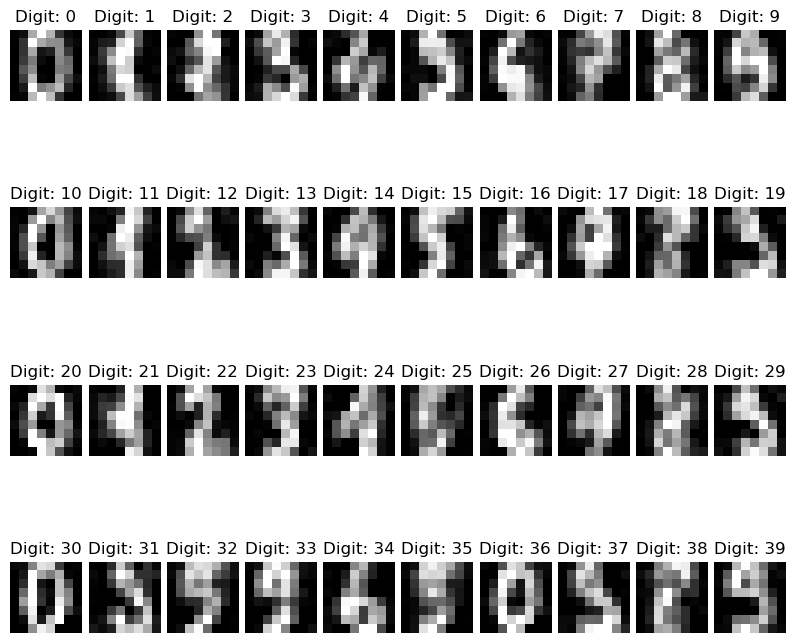

In [47]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)